# Задача определения наилучшей дислокации множества подразделений (MCLP)

В общем виде процесс решения задачи определения наилучшей дислокации множества подразделений можно представить следующим образом:

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия")

  metrics["**МЕТРИКИ**"]

  blp_algs["**ЭВРИСТИЧЕСКИЕ АЛГОРИТМЫ MCLP**
        ---
        ADD
        ---
        GNS, GA, SAA, GA+GNS"]

  blp("**ВЫБОР ДИСЛОКАЦИИ**")
        
  model --> result
  metrics --> analyze
  result --> analyze
  analyze --> blp
  blp_algs --> blp
  blp --> model

```

Поиск наилучшей дислокации подразумевает выдвижение гипотез о размещении подразделений и моделирование параметров реагирования прибытия, после чего на основании проведенного анализа делается вывод о том, насколько предложенное размещение подразделений оптимально.

В **Генезис** реализованы следующие алгоритмы решения задачи MCLP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` Алгоритм жадного добавления (ADD) - *рекомендуемый*,
- Прочие:
  - `genesis.mclp.BestNodesKoptG` Модульный алгоритм Генезис (GNS)
  - `genesis.mclp.BestNodesGA` Генетический алгоритм (GA)
  - `genesis.mclp.BestNodesSA` Алгоритм имитации отжига (SAA)
  - `fire_units.mclp.BestNodesGAKopt` Гибридный алгоритм Генетический алгоритм + Генезис (GA+GNS)

Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.033


In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки при размещении пожарного депо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Матрица прибытия {.unnumbered}

In [3]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 2000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Расчет без учета имеющихся подразделений {.unnumbered}

Определение оптимальной дислокации 4 подразделений с целью минимизации индекса прикрытия (10 минутная зона).

ИП-10: 68.35429545939033


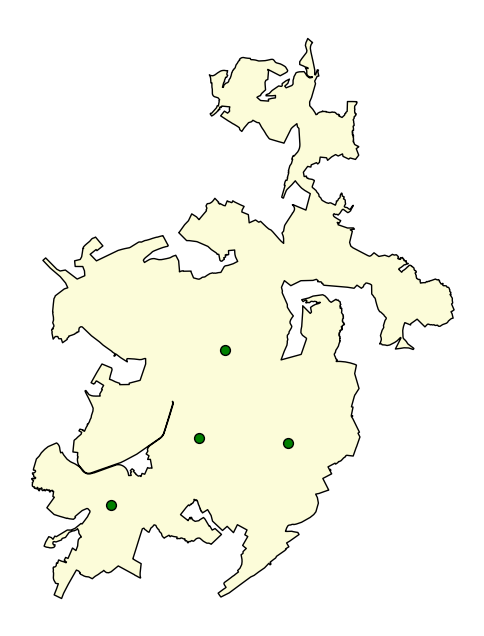

In [4]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 4      # Расчет проводится для определения оптимальной дислокации 4 подразделений

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

### Расчет с учетом имеющихся подразделений {.unnumbered}

Определение оптимальной дислокации 4 подразделений с целью минимизации индекса прикрытия (10 минутная зона). С учетом существующих подразделений.

ИП-10: 92.77339586442123


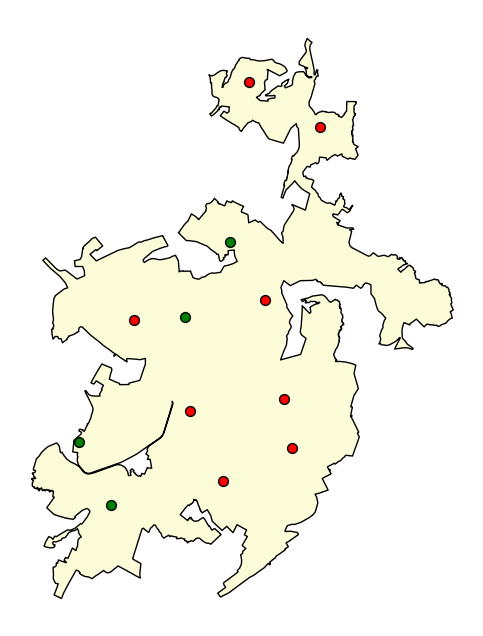

In [5]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 4      # Расчет проводится для определения оптимальной дислокации 4 подразделений

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Дополнительные способы

### Модульный алгоритм Генезис (GNS) {.unnumbered}

Определение размещения 3 подразделений с учетом существующих.

ИП-10: 76.27371562566617


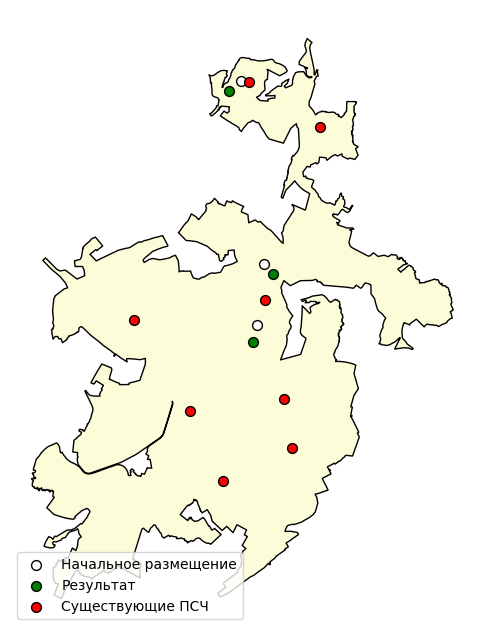

In [ ]:
from genesis.mclp import BestNodesKoptG
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean     # Версия алгоритма подъема по холмам с локальной оптимизацией

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1000]: 'псч-1',
    g_nodes_list[2000]: 'псч-2',
    g_nodes_list[3000]: 'псч-3',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция определения лучшего узла
best_point = BestNodeHillClimbing_HD_Max_Mean(
    state_function      = state,
    metric_function     = metric,
)

## Сборка и инициализация алгоритма GNS
gns = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = best_point,
)


# 3. Расчет GNS
best_nodes, best_metric = gns(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
        static_nodes    = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Генетический алгоритм (GA) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью минимизации среднего времени прибытия к зданиям.

Эпоха: 0, Метрика: 11.11475344814694
Эпоха: 1, Метрика: 11.11475344814694
Эпоха: 2, Метрика: 11.11475344814694
Эпоха: 3, Метрика: 10.863844278519757
Эпоха: 4, Метрика: 10.435449353918997
Эпоха: 5, Метрика: 10.435449353918997
Эпоха: 6, Метрика: 10.435449353918997
Эпоха: 7, Метрика: 9.990494092411474
Эпоха: 8, Метрика: 9.920372194270202
Эпоха: 9, Метрика: 9.748304472015494
Среднее время прибытия: 9.748304472015494


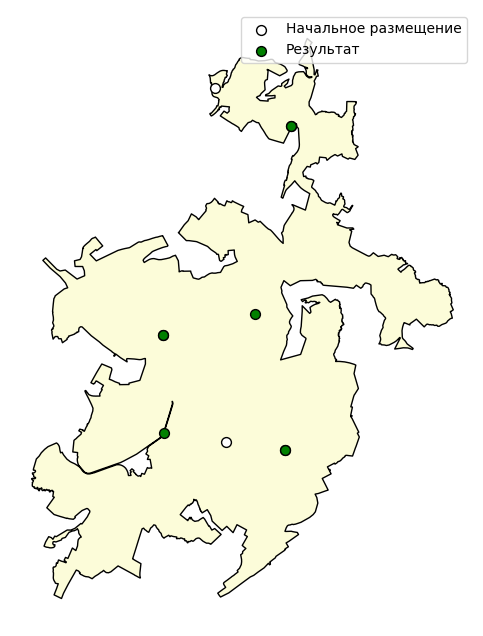

In [ ]:
from genesis.mclp import BestNodesGA
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings) # Используется метрика среднего времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Сборка и инициализация алгоритма GNS
ga = BestNodesGA(  
    state_function      = state,
    metric_function     = metric,
    node_selector       = selector,
    population_size     = 30,               # Размер популяции
    epochs              = 10,               # Количество эпох
    elite_size          = 15,               # Размер элитной группы
    mutation_rate       = 0.5,             # Вероятность мутации
    mutation_max_count  = 3,                # Максимальное количество мутаций
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


# 3. Расчет GA
best_nodes, best_metric = ga(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('Среднее время прибытия:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Алгоритм имитации отжига (SAA) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью максимизации ИП-8 (*для примера*).

In [ ]:
from genesis.mclp import BestNodesSA
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=8) # Используется метрика среднего времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
turn_end = lambda turn, best_metric, **kwargs: print(f'Шаг: {turn}, Метрика: {best_metric}  ', end='\r')

## Сборка и инициализация алгоритма GNS
saa = BestNodesSA(  
    state_function      = state,
    metric_function     = metric,
    node_selector       = selector,
    turn_end_function   = turn_end,        # Вывод хода расчета по итогам шага расчета
)


# 3. Расчет GA
best_nodes, best_metric = saa(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('ИП-8:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Гибридный алгоритм Генетический алгоритм + Генезис (GA+GNS) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью минимизации максимального времени прибытия.

Эпоха: 0, Метрика: 30.716719009387976
Эпоха: 1, Метрика: 30.716719009387976
Эпоха: 2, Метрика: 29.74033738995605
Эпоха: 3, Метрика: 28.438680606656018
Эпоха: 4, Метрика: 28.438680606656018
Эпоха: 5, Метрика: 28.438680606656018
Эпоха: 6, Метрика: 28.438680606656018
Эпоха: 7, Метрика: 28.438680606656018
Эпоха: 8, Метрика: 28.438680606656018
Эпоха: 9, Метрика: 28.438680606656018
Максимальное время прибытия: 28.438680606656018


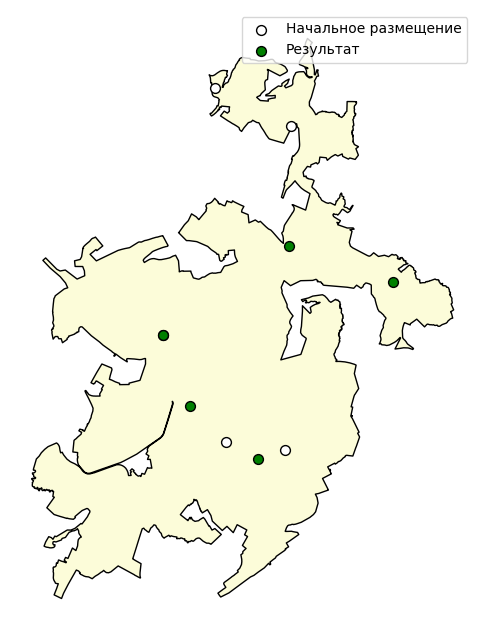

In [ ]:
from genesis.mclp import BestNodesKoptG
from fire_units.mclp import BestNodesGAKopt
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings, f=np.max) # Используется метрика максимального времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Алгоритм Генезис
## Функция определения лучшего узла
best_point = BestNodeHillClimbing_HD_Max_Mean(
    state_function      = state,
    metric_function     = metric,
)

## Сборка и инициализация алгоритма GNS
gns = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = best_point,
    iterations          = 3,
)

## Сборка и инициализация алгоритма GNS
gagns = BestNodesGAKopt(  
    state_function      = state,
    metric_function     = metric,
    kopt_function       = gns,              # Функция Генезис
    node_selector       = selector,
    population_size     = 30,               # Размер популяции
    epochs              = 10,               # Количество эпох
    elite_size          = 15,               # Размер элитной группы
    mutation_rate       = 0.5,              # Вероятность мутации
    mutation_max_count  = 3,                # Максимальное количество мутаций
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


# 3. Расчет GA
best_nodes, best_metric = gagns(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('Максимальное время прибытия:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Новые ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()